In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
df = pd.read_csv("loan_data.csv")

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No,1.0
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes,0.0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No,1.0
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No,1.0
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No,1.0


In [ ]:
df.shape

(13192, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13192 entries, 0 to 13191
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      13192 non-null  float64
 1   person_gender                   13192 non-null  object 
 2   person_education                13192 non-null  object 
 3   person_income                   13192 non-null  float64
 4   person_emp_exp                  13192 non-null  int64  
 5   person_home_ownership           13192 non-null  object 
 6   loan_amnt                       13192 non-null  float64
 7   loan_intent                     13192 non-null  object 
 8   loan_int_rate                   13191 non-null  float64
 9   loan_percent_income             13191 non-null  float64
 10  cb_person_cred_hist_length      13191 non-null  float64
 11  credit_score                    13191 non-null  float64
 12  previous_loan_defaults_on_file  

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,13192.000000,13192.000000,13192.000000,13192.000000,13191.000000,13191.000000,13191.000000,13191.000000,13191.000000
mean,23.598620,65540.724378,1.663811,8683.781837,10.937914,0.144580,2.996058,626.280570,0.232583
std,2.441425,33016.662566,2.653862,5709.347333,3.048846,0.087066,0.818466,49.523674,0.422494
min,20.000000,12231.000000,0.000000,500.000000,5.420000,0.000000,2.000000,421.000000,0.000000
25%,22.000000,43963.750000,0.000000,4800.000000,8.000000,0.080000,2.000000,595.000000,0.000000
50%,23.000000,60996.500000,1.000000,7200.000000,11.010000,0.130000,3.000000,634.000000,0.000000
75%,25.000000,79976.250000,3.000000,11000.000000,13.060000,0.190000,4.000000,663.000000,0.000000
max,144.000000,600891.000000,125.000000,35000.000000,20.000000,0.660000,4.000000,807.000000,1.000000


In [ ]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,1
loan_percent_income,1


Total Applicants : 13192
Loan Rejected    : 10123
Loan Approved    : 3069
Rejected Percentage : 76.74 %
Approved Percentage : 23.26 %


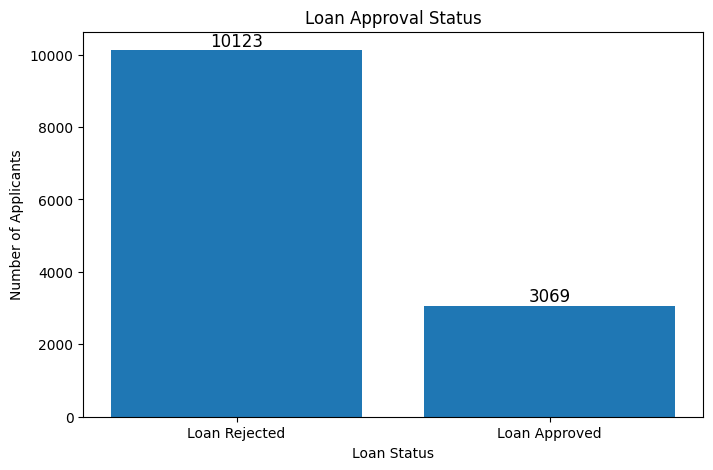

In [ ]:
# Loan Approval Distribution

loan_counts = df["loan_status"].value_counts().sort_index()

rejected = loan_counts[0]
approved = loan_counts[1]

total = rejected + approved

print("Total Applicants :", total)
print("Loan Rejected    :", rejected)
print("Loan Approved    :", approved)

print("Rejected Percentage :", round((rejected / total) * 100, 2), "%")
print("Approved Percentage :", round((approved / total) * 100, 2), "%")


# Plot
plt.figure(figsize=(8,5))

bars = plt.bar(
    ["Loan Rejected", "Loan Approved"],
    [rejected, approved]
)

plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

# Display count on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.show()

In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_3601/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
label = LabelEncoder()

categorical_columns = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

for col in categorical_columns:
    df[col] = label.fit_transform(df[col])

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,5,16.02,0.49,3.0,561.0,0,1.0
1,21.0,0,3,12282.0,0,2,1000.0,2,11.14,0.08,2.0,504.0,1,0.0
2,25.0,0,3,12438.0,3,0,5500.0,4,12.87,0.44,3.0,635.0,0,1.0
3,23.0,0,1,79753.0,0,3,35000.0,4,15.23,0.44,2.0,675.0,0,1.0
4,24.0,1,4,66135.0,1,3,35000.0,4,14.27,0.53,4.0,586.0,0,1.0


In [ ]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8550 - loss: 0.3097 - val_accuracy: 0.8896 - val_loss: 0.2404
Epoch 2/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8876 - loss: 0.2351 - val_accuracy: 0.8868 - val_loss: 0.2320
Epoch 3/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8927 - loss: 0.2236 - val_accuracy: 0.8944 - val_loss: 0.2164
Epoch 4/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8940 - loss: 0.2174 - val_accuracy: 0.8958 - val_loss: 0.2205
Epoch 5/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8992 - loss: 0.2134 - val_accuracy: 0.9000 - val_loss: 0.2118
Epoch 6/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9004 - loss: 0.2096 - val_accuracy: 0.9015 - val_loss: 0.2108
Epoch 7/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9041 - loss: 0.2056 - val_accuracy: 0.8986 - val_loss: 0.2124
Epoch 8/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9045 - loss: 0.2032 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)

print("Accuracy :", accuracy)

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8768 - loss: 0.3130
Loss : 0.3129808008670807
Accuracy : 0.8768472671508789


In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


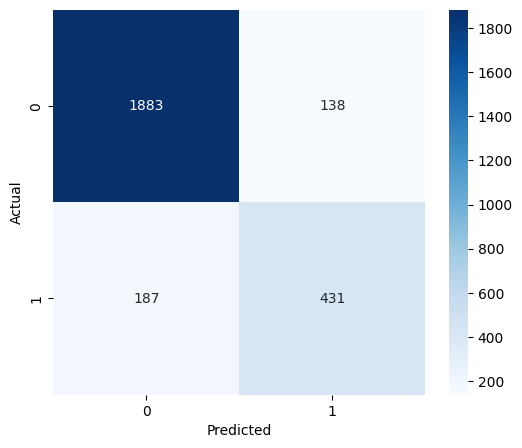

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.93      0.92      2021
         1.0       0.76      0.70      0.73       618

    accuracy                           0.88      2639
   macro avg       0.83      0.81      0.82      2639
weighted avg       0.87      0.88      0.88      2639



In [ ]:
model.save("Loan_Approval_ANN.h5")

In [ ]:
print("Gender:")
print(df.groupby("person_gender").size())

print("\nEducation:")
print(df.groupby("person_education").size())

print("\nHome Ownership:")
print(df.groupby("person_home_ownership").size())

print("\nLoan Intent:")
print(df.groupby("loan_intent").size())

print("\nPrevious Loan Default:")
print(df.groupby("previous_loan_defaults_on_file").size())

Gender:
person_gender
0    5919
1    7273
dtype: int64

Education:
person_education
0    3340
1    3998
2      39
3    3768
4    2047
dtype: int64

Home Ownership:
person_home_ownership
0    4739
1      49
2     951
3    7453
dtype: int64

Loan Intent:
loan_intent
0    2158
1       1
2    3066
3    1140
4    2381
5    2146
6    2300
dtype: int64

Previous Loan Default:
previous_loan_defaults_on_file
0    6455
1    6737
dtype: int64


In [ ]:
age = float(input("Enter Age: "))
gender = int(input("Gender (encoded value): "))
education = int(input("Education (encoded value): "))
income = float(input("Income: "))
experience = float(input("Employment Experience: "))
home = int(input("Home Ownership (encoded value): "))
loan_amount = float(input("Loan Amount: "))
intent = int(input("Loan Intent (encoded value): "))
interest = float(input("Interest Rate: "))
loan_percent = float(input("Loan Percent Income: "))
credit_history = float(input("Credit History Length: "))
credit_score = float(input("Credit Score: "))
previous_default = int(input("Previous Default (encoded value): "))

Enter Age: 30
Gender (encoded value): 0
Education (encoded value): 4
Income: 35000
Employment Experience: 3
Home Ownership (encoded value): 2
Loan Amount: 50000
Loan Intent (encoded value): 5
Interest Rate: 8
Loan Percent Income: 0.33
Credit History Length: 2
Credit Score: 333
Previous Default (encoded value): 0


In [ ]:
sample = np.array([[

    age,
    gender,
    education,
    income,
    experience,
    home,
    loan_amount,
    intent,
    interest,
    loan_percent,
    credit_history,
    credit_score,
    previous_default

]])

In [ ]:
sample = scaler.transform(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = model.predict(sample)

if prediction[0][0] >= 0.5:
    print("Loan Approved")
else:
    print("Loan Rejected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Loan Approved
